# Tarea 4. Gracida Salgado Angel David

Primero, vamos a aplicar el método sin sklearn, para obtener la curva de la varianza explicada acumulada.

In [2]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X = df[diabetes['feature_names']]
y = diabetes.target

In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [4]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [5]:
#Estandarizamos manualmente
X_mean = X.mean()
X_std = X.std()
Z = (X - X_mean) / X_std

In [6]:
#Sacamos la matriz de covarianza
c=Z.cov()

In [7]:
#Sacamos eigenvalores y eigenvectores y los ordenamos en orden descendente
import numpy as np
eigenvalues, eigenvectors = np.linalg.eig(c)
print('Valores propios:\n', eigenvalues)
print('Forma de los valores propios:', eigenvalues.shape)
print('Forma de los vectores propios:', eigenvectors.shape)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Valores propios:
 [4.02421075 1.49231968 1.20596626 0.9554764  0.00856073 0.07832002
 0.66218139 0.43368204 0.60271708 0.53656565]
Forma de los valores propios: (10,)
Forma de los vectores propios: (10, 10)


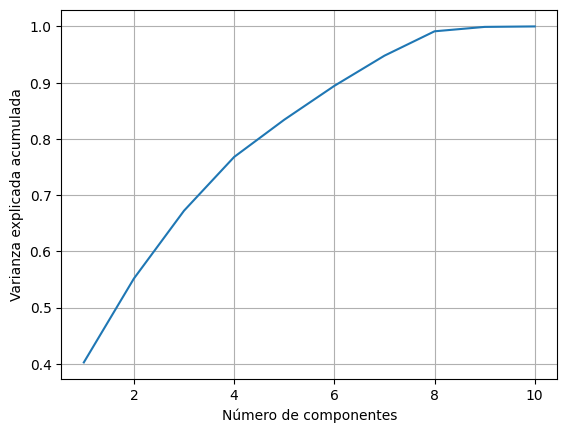

In [8]:
#Graficamos la curva de la varianza explicada acumulada, para ver que número de componentes principales nos convienen
import matplotlib.pyplot as plt
explained_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
plt.plot(range(1, len(explained_var) + 1), explained_var)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid()
plt.show()

De la gráfica anterior, vemos que para tener un 80% de la varianza, necesitamos al menos 5 componentes principales, por lo que ahora si podemos aplicar el algoritmo con scikit-learn con el número de componentes adecuado.

1) Aplica la estandarización de las variables utilizando StandardScaler.

In [9]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X = df[diabetes['feature_names']]
y = diabetes.target

In [10]:
#Estandarizamos los datos de caracteristicas con standarscaller
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
print(X_scaled)

[[ 0.80050009  1.06548848  1.29708846 ... -0.05449919  0.41853093
  -0.37098854]
 [-0.03956713 -0.93853666 -1.08218016 ... -0.83030083 -1.43658851
  -1.93847913]
 [ 1.79330681  1.06548848  0.93453324 ... -0.05449919  0.06015558
  -0.54515416]
 ...
 [ 0.87686984  1.06548848 -0.33441002 ... -0.23293356 -0.98564884
   0.32567395]
 [-0.9560041  -0.93853666  0.82123474 ...  0.55838411  0.93616291
  -0.54515416]
 [-0.9560041  -0.93853666 -1.53537419 ... -0.83030083 -0.08875225
   0.06442552]]


Aplica PCA de forma que se preserve al menos el 80% de la varianza total
del conjunto de datos. ¿Cuál es el número de componentes principales
obtenidos?

In [12]:

from sklearn.decomposition import PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

3) Haz una comparación del tamaño aproximado en memoria del dataset
original y del dataset reducido (en kilobytes).

In [14]:
import pandas as pd
#primero los transformamos en datafranes
dfpca =pd.DataFrame(X_pca)
df_scaled = pd.DataFrame(X_scaled)

#segun la pagina de la libreria de pandas: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.memory_usage.html,
#la función .memory_usage() me devuelve el uso de memoria de cada columna en bytes, y aplicando sum(), me devuelve el total del peso
#en bytes del dataframe completo, por lo que lo aplicamos a ambos dataframes de arriba

memoria_bytes1 = dfpca.memory_usage(deep=True).sum()
memoria_bytes2 = df_scaled.memory_usage(deep=True).sum()

#como lo devuelve en bytes, hacemos la conversión de 1 Kb= 1024 bytes
memoria_kb1 = memoria_bytes1 / 1024
memoria_kb2 = memoria_bytes2 / 1024

print("Memoria del dataframe reducido",memoria_kb1,"Kb")
print("Memoria del dataframe estandarizado",memoria_kb2,"Kb")
print('El dataset de los componentes preincipales se ha reducido')


Memoria del dataframe reducido 17.39453125 Kb
Memoria del dataframe estandarizado 34.66015625 Kb
El dataset de los componentes preincipales se ha reducido


4) Proyecta los datos estandarizados al espacio reducido y luego reconstruye
una aproximación de los datos originales usando:

In [15]:
X_reduced = pca.transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_reduced)

5) Calcula el error de reconstrucción utilizando:

In [16]:
from sklearn.metrics import mean_squared_error

mean_squared_error(X_scaled,X_reconstructed)
#El error es cercano a cero, por lo que es una buena reconstrucción, pero podría ser mejor


0.16598455185932312

6) Calcula el MSE para k = 1, 2, . . . , 10 componentes y grafica el MSE en
función de k (lo que se llama curva de error de reconstrucción en PCA). A partir de qué número de componentes el error deja de disminuir significativamente?

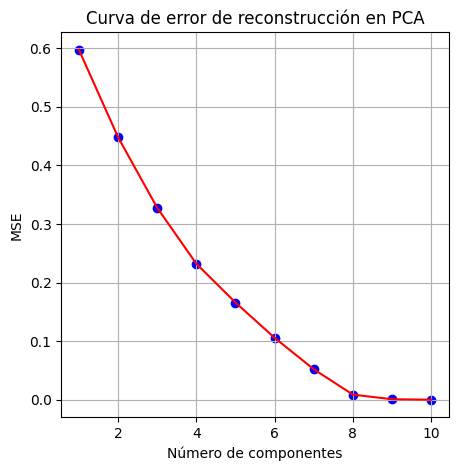

In [17]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

H=[]
for k in range(1, 11):
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    X_reduced = pca.transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_reduced)
    H.append(mean_squared_error(X_scaled,X_reconstructed))

ax,fig=plt.subplots(figsize=(5,5))
plt.scatter(range(1, 11),H,color="blue")
plt.title("Curva de error de reconstrucción en PCA")
plt.plot(range(1, 11),H,color="red")
plt.xlabel("Número de componentes")
plt.ylabel("MSE")
plt.grid()
plt.show()



Apartir de la componente k=8, el error deja de disminuir significativamente, tendiendo a cero casi como una constante